# Deep Water problem CPU version

In [1]:
using ProgressMeter, FFTW, LinearAlgebra, Plots

In [2]:
abstract type AbstractModel end
abstract type InitialData end

In [3]:
struct Mesh

    N    :: Int64
    x    :: Vector{Float64}
    kmin :: Float64
    kmax :: Float64
    k    :: Vector{Float64}

    function Mesh(param :: NamedTuple)

        xmin = - Float64(param.L)
        xmax =   Float64(param.L)
        N    =   param.N
        
        dx   = (xmax-xmin)/N
        x    = zeros(Float64, N)
        x   .= range(xmin, stop=xmax, length=N+1)[1:end-1] 
        dk   = 2π/(N*dx)
        kmin = -N/2*dk
        kmax = (N/2-1)*dk
        k    = zeros(Float64, N)
        k   .= dk .* vcat(0:N÷2-1, -N÷2:-1)

        new( N, x, kmin, kmax, k)

    end

end

In [4]:
struct Times

    Nt   :: Int
    dt   :: Float64

    function Times( dt , tfin)
        Nt = length(0:dt:tfin)
        new( Nt, dt)
    end

end

In [5]:
"""
    RK4(params)

Runge-Kutta fourth order solver.

"""
mutable struct RK4
    
    Uhat :: Array{ComplexF64,2}
    dU   :: Array{ComplexF64,2}

    function RK4( param::NamedTuple, model::AbstractModel )

        n = param.N

        Uhat = zeros(ComplexF64, (n,2))
        dU   = zeros(ComplexF64, (n,2))

        new( Uhat, dU)

    end

end

RK4

In [6]:
function step!(s  :: RK4,
               f! :: AbstractModel,
               U  :: Array{ComplexF64,2},
               dt :: Float64)

    
    Threads.@threads for i in eachindex(U)
        @inbounds s.Uhat[i] = U[i]
    end

    f!( s.Uhat )

    Threads.@threads for i in eachindex(U)
        @inbounds s.dU[i]   = s.Uhat[i]
        @inbounds s.Uhat[i] = U[i] + dt/2 * s.Uhat[i]
    end

    f!( s.Uhat )

    Threads.@threads for i in eachindex(U)
        @inbounds s.dU[i]   += 2 * s.Uhat[i]
        @inbounds s.Uhat[i]  = U[i] + dt/2 * s.Uhat[i]
    end

    f!( s.Uhat )

    Threads.@threads for i in eachindex(U)
        @inbounds s.dU[i]   += 2 * s.Uhat[i]
        @inbounds s.Uhat[i]  = U[i] + dt * s.Uhat[i]
    end

    f!( s.Uhat )

    Threads.@threads for i in eachindex(U)
        @inbounds s.dU[i] += s.Uhat[i]
        @inbounds U[i]    += dt/6 * s.dU[i]
    end

end

step! (generic function with 1 method)

In [7]:
struct BellCurve <: InitialData

    h :: Vector{ComplexF64}
    u :: Vector{ComplexF64}

    function BellCurve(p :: NamedTuple,theta :: Real)

        mesh  = Mesh(p)
        h     = zeros(ComplexF64, mesh.N)
        h    .= exp.(.-((abs.(mesh.x)).^theta).*log(2))
        u     = zeros(ComplexF64, mesh.N)

        new( h, u )

    end

end

In [8]:
"""
    Matsuno(params)

"""
mutable struct Matsuno <: AbstractModel

    label    :: String
    datasize :: Int
    Γ        :: Array{Float64,1}
    Dx       :: Array{ComplexF64,1}
    H        :: Array{ComplexF64,1}
    Π⅔       :: BitArray{1}
    ϵ        :: Float64
    hnew     :: Vector{ComplexF64}
    unew     :: Vector{ComplexF64}
    I₀       :: Vector{ComplexF64}
    I₁       :: Vector{ComplexF64}
    I₂       :: Vector{ComplexF64}
    I₃       :: Vector{ComplexF64}

    Px       :: FFTW.FFTWPlan

    function Matsuno(param::NamedTuple)

        label    = "Matsuno"
        datasize = 2
        ϵ        = param.ϵ
        mesh     = Mesh(param)
        Γ        = abs.(mesh.k)
        Dx       =  1im * mesh.k        # Differentiation
        H        = -1im * sign.(mesh.k) # Hilbert transform
        Π⅔       = Γ .< mesh.kmax * 2/3 # Dealiasing low-pass filter

        hnew = zeros(ComplexF64, mesh.N)
        unew = zeros(ComplexF64, mesh.N)

        I₀ = zeros(ComplexF64, mesh.N)
        I₁ = zeros(ComplexF64, mesh.N)
        I₂ = zeros(ComplexF64, mesh.N)
        I₃ = zeros(ComplexF64, mesh.N)

        Px  = plan_fft(hnew; flags = FFTW.MEASURE)

        new(label, datasize, Γ, Dx, H, Π⅔, ϵ,
            hnew, unew, I₀, I₁, I₂, I₃, Px)
    end
end

Matsuno

In [9]:
function (m::Matsuno)( U :: Array{ComplexF64,2})


    Threads.@threads for i in eachindex(m.hnew)
        @inbounds m.hnew[i] = m.Γ[i] * U[i,1]
    end

    ldiv!(m.unew, m.Px, m.hnew )

    Threads.@threads for i in eachindex(m.hnew)
        @inbounds m.hnew[i] = m.Dx[i] * U[i,1]
    end

    ldiv!(m.I₁, m.Px, m.hnew)

    Threads.@threads for i in eachindex(m.unew)
        @inbounds m.unew[i] *= m.I₁[i]
    end

    mul!(m.I₁, m.Px, m.unew)

    Threads.@threads for i in eachindex(m.hnew)
        @inbounds m.I₁[i] = m.I₁[i] * m.ϵ * m.Π⅔[i] - m.hnew[i]
    end

    ldiv!(m.hnew, m.Px, view(U,:,1))
    ldiv!(m.unew, m.Px, view(U,:,2))

    Threads.@threads for i in eachindex(m.hnew)
        @inbounds m.I₂[i] = m.hnew[i] * m.unew[i]
    end

    mul!(m.I₃, m.Px, m.I₂)

    Threads.@threads for i in eachindex(m.H)
        @inbounds U[i,1]  = m.H[i] * U[i,2]
        @inbounds m.I₀[i] = m.Γ[i] * U[i,2]
    end

    ldiv!(m.I₂, m.Px, m.I₀)

    Threads.@threads for i in eachindex(m.hnew)
        @inbounds m.I₂[i] *= m.hnew[i]
    end

    mul!(m.hnew, m.Px, m.I₂)

    Threads.@threads for i in eachindex(m.unew)
        @inbounds U[i,1] -= (m.I₃[i] * m.Dx[i] + m.hnew[i] * m.H[i]) * m.ϵ * m.Π⅔[i]
        @inbounds m.I₃[i]  = m.unew[i]^2
    end 

    mul!(m.unew, m.Px, m.I₃)

    Threads.@threads for i in eachindex(m.unew)
        @inbounds U[i,2]  =  m.I₁[i] - m.unew[i] * m.Dx[i] * m.ϵ/2 * m.Π⅔[i]
    end 

end

In [10]:
function create_animation( mesh, times, model, data )

    prog = Progress(times.Nt,1)

    hr = zeros(Float64,mesh.N)
    ur = zeros(Float64,mesh.N)

    anim = @animate for l in 1:size(data)[end]

        pl = plot(layout=(2,1))

        hr .= real(ifft(view(data,:,1,l)))
        ur .= real(ifft(view(data,:,2,l)))

        plot!(pl[1,1], mesh.x, hr;
              ylims=(-0.6,1),
              title="physical space",
              label=model.label)

        plot!(pl[2,1], fftshift(mesh.k),
              log10.(1e-18.+abs.(fftshift(fft(hr))));
              ylims=(-20,5),
              title="frequency",
              label=model.label)

        next!(prog)

    end when mod(l, 100) == 0

    gif(anim, "anim_"*model.label*".gif", fps=15)

end

create_animation (generic function with 1 method)

In [11]:
function main_cpu( N :: Int64 ; animation = true )

    param = ( ϵ  = 1/2,
              N  = N,
              L  = 10.,
              T  = 5.,
              dt = 0.001 )
    
    mesh    = Mesh(param)
    times   = Times(param.dt, param.T)
    init    = BellCurve(param,2.5)
    model   = Matsuno(param)
    solver  = RK4(param,model)
    
    U       = zeros(ComplexF64,(mesh.N,2))
    U[:,1] .= model.Π⅔ .* fft(init.h) 
    U[:,2] .= model.Π⅔ .* fft(init.u)

    dt = times.dt
    data = zeros(ComplexF64,(mesh.N,2,times.Nt))

    @showprogress 1 for j in 1:times.Nt
        step!(solver, model, U, dt)
        data[:,:,j] .= U
    end

    if animation
        create_animation( mesh, times, model, data )
    end

end

main_cpu (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:15
Progress: 100%|█████████████████████████████████████████| Time: 0:00:09
[ Info: Saved animation to /home/pnavaro/JuliaNantes2019/anim_Matsuno.gif


Plots.AnimatedGif("/home/pnavaro/JuliaNantes2019/anim_Matsuno.gif")
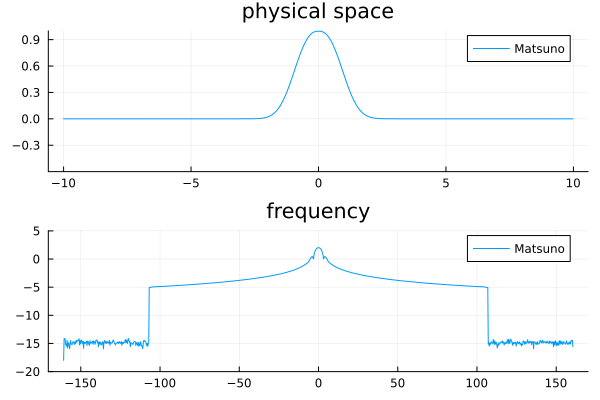

In [14]:
main_cpu( 2^10 ; animation = true )